⚠️ **Privacidad:** las salidas se eliminaron porque los datos contienen información de estudiantes menores. Ejecute este cuaderno solo en un entorno institucional autorizado y no publique tablas con nombres, RUDE o fechas de nacimiento.


# Objetivo 2: Analizar los datos para identificar patrones de rezago académico

En este notebook analizaremos el dataset final para encontrar los factores asociados como materias críticas y desempeño.

In [1]:
!pip install matplotlib

In [2]:
import pandas as pd

dataset = pd.read_csv("../data/03_Datasets_Procesados/primaria_dataset.csv")
dataset.head()


,gestion,anio_escolaridad,paralelo,nro.,paterno,materno,nombres,rude,gen,fecha_nac,...,edu_musical,art_plasticas,matematica,tec_tecnologica,cs_naturales,valores_religion,archivo_origen,rezago,num_materias_reprobadas,promedio_general
0,2022,PRIMERO,B,1,NaN,FERNANDEZ,AYELEN BELEN,809800682020086,F,09-07-2015,...,84.0,87.0,89.0,90.0,90.0,91.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,88.333333
1,2022,PRIMERO,B,2,NaN,HINOJOSA,ARELI LUCIA,609000282018010,F,31-10-2013,...,NaN,NaN,NaN,NaN,NaN,NaN,boletin_centralizador_80980027_12_Primero_B_20...,0,0,NaN
2,2022,PRIMERO,B,3,ALANES,FUENTES,DESIRE CIELO,809804752020027,F,11-08-2015,...,79.0,69.0,67.0,69.0,66.0,92.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,73.777778
3,2022,PRIMERO,B,4,ALVAREZ,SEJAS,REYCHEL,809801842020002,F,10-09-2015,...,73.0,54.0,55.0,54.0,52.0,65.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,59.333333
4,2022,PRIMERO,B,5,APAZA,CARVAJAL,KAROLAY FELISA,809801202020120,F,28-04-2016,...,56.0,52.0,51.0,51.0,51.0,41.0,boletin_centralizador_80980027_12_Primero_B_20...,1,2,51.444444


In [3]:
dataset.shape
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gestion                  1118 non-null   int64  
 1   anio_escolaridad         1118 non-null   object 
 2   paralelo                 1118 non-null   object 
 3   nro.                     1118 non-null   int64  
 4   paterno                  1091 non-null   object 
 5   materno                  1116 non-null   object 
 6   nombres                  1118 non-null   object 
 7   rude                     1118 non-null   object 
 8   gen                      1118 non-null   object 
 9   fecha_nac                1118 non-null   object 
 10  lugnac                   1067 non-null   object 
 11  numeroc.i.               1092 non-null   float64
 12  estadomatricula          1118 non-null   object 
 13  com_lenguajes            1030 non-null   float64
 14  cs_sociales             

In [4]:
dataset["rezago"].value_counts()
dataset["rezago"].value_counts(normalize=True) * 100


rezago
0    97.942755
1     2.057245
Name: proportion, dtype: float64

In [5]:
materias = [
    "com_lenguajes",
    "cs_sociales",
    "edu_fisica",
    "edu_musical",
    "art_plasticas",
    "matematica",
    "tec_tecnologica",
    "cs_naturales",
    "valores_religion"
]

notas_validas = dataset[materias].notna()
tasas_reprobacion = (
    dataset[materias].lt(51)
    .where(notas_validas)
    .mean()
    .sort_values(ascending=False) * 100
)
tasas_reprobacion


com_lenguajes        2.23301
matematica           1.84466
cs_naturales        1.262136
cs_sociales         1.067961
valores_religion    1.067961
tec_tecnologica     0.582524
edu_musical         0.485437
art_plasticas       0.485437
edu_fisica          0.194175
dtype: object

In [6]:
dataset.groupby("rezago")[materias].mean()

,com_lenguajes,cs_sociales,edu_fisica,edu_musical,art_plasticas,matematica,tec_tecnologica,cs_naturales,valores_religion
rezago,,,,,,,,,
0,74.486594,74.479643,78.019861,77.409136,75.926514,73.472691,76.271102,75.040715,70.329692
1,45.956522,49.173913,58.739130,57.608696,53.434783,47.043478,53.130435,49.869565,49.826087


In [7]:
dataset

,gestion,anio_escolaridad,paralelo,nro.,paterno,materno,nombres,rude,gen,fecha_nac,...,edu_musical,art_plasticas,matematica,tec_tecnologica,cs_naturales,valores_religion,archivo_origen,rezago,num_materias_reprobadas,promedio_general
0,2022,PRIMERO,B,1,NaN,FERNANDEZ,AYELEN BELEN,809800682020086,F,09-07-2015,...,84.0,87.0,89.0,90.0,90.0,91.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,88.333333
1,2022,PRIMERO,B,2,NaN,HINOJOSA,ARELI LUCIA,609000282018010,F,31-10-2013,...,NaN,NaN,NaN,NaN,NaN,NaN,boletin_centralizador_80980027_12_Primero_B_20...,0,0,NaN
2,2022,PRIMERO,B,3,ALANES,FUENTES,DESIRE CIELO,809804752020027,F,11-08-2015,...,79.0,69.0,67.0,69.0,66.0,92.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,73.777778
3,2022,PRIMERO,B,4,ALVAREZ,SEJAS,REYCHEL,809801842020002,F,10-09-2015,...,73.0,54.0,55.0,54.0,52.0,65.0,boletin_centralizador_80980027_12_Primero_B_20...,0,0,59.333333
4,2022,PRIMERO,B,5,APAZA,CARVAJAL,KAROLAY FELISA,809801202020120,F,28-04-2016,...,56.0,52.0,51.0,51.0,51.0,41.0,boletin_centralizador_80980027_12_Primero_B_20...,1,2,51.444444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,2023,PRIMERO,A,28,TORREZ,COLQUE,EUGENE MATIAS,8098008320214763,M,17-03-2017,...,63.0,66.0,60.0,61.0,63.0,56.0,boletin_centralizador_80980027_12_Primero_A_20...,0,0,61.666667
1114,2023,PRIMERO,A,29,TORRICO,GONZALES,AGUSTIN MATTEO,8098055120215690,M,10-04-2017,...,87.0,74.0,71.0,73.0,78.0,84.0,boletin_centralizador_80980027_12_Primero_A_20...,0,0,77.333333
1115,2023,PRIMERO,A,30,VARGAS,MONTENEGRO,GUSTAVO ANDRE,8098060020213014,M,29-12-2016,...,87.0,79.0,76.0,71.0,71.0,76.0,boletin_centralizador_80980027_12_Primero_A_20...,0,0,76.222222
1116,2023,PRIMERO,A,31,VILLEGAS,DELGADILLO,SEBASTIAN\nNICOLAS,8098051020225260,M,30-12-2016,...,68.0,83.0,86.0,86.0,87.0,83.0,boletin_centralizador_80980027_12_Primero_A_20...,0,0,83.333333


In [8]:
dataset["num_materias_reprobadas"].value_counts().sort_index()


num_materias_reprobadas
0    1095
2       7
3       4
4       3
5       3
6       2
7       2
8       2
Name: count, dtype: int64

In [9]:
dataset.groupby("rezago")["num_materias_reprobadas"].mean()


rezago
0    0.000000
1    4.130435
Name: num_materias_reprobadas, dtype: float64

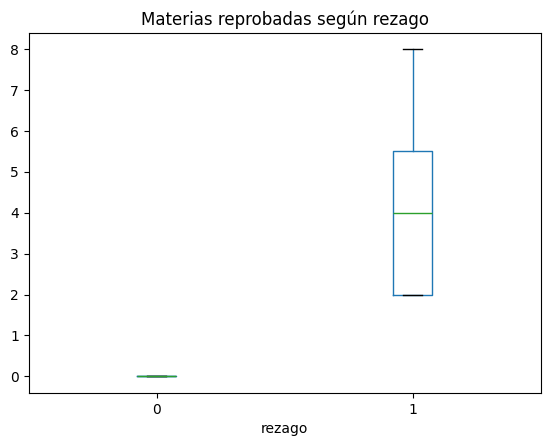

In [10]:
import matplotlib.pyplot as plt

dataset.boxplot(
    column="num_materias_reprobadas",
    by="rezago",
    grid=False
)
plt.title("Materias reprobadas según rezago")
plt.suptitle("")
plt.show()
